In [8]:
import numpy as np

In [9]:
import os
import glob

globalfits = glob.glob("/scratch-cbe/users/alikaan.gueven/SBIPDF/output/toys/globalfit/*.npz")


In [10]:
x = np.load(globalfits[0])
x.files

['config', 'toys_npz', 'toy_ids', 'region_ids', 'c_names', 'n2ll_min', 'c_hat']

In [11]:
x['c_hat'].shape

(1, 6)

In [12]:
x.files

['config', 'toys_npz', 'toy_ids', 'region_ids', 'c_names', 'n2ll_min', 'c_hat']

In [15]:
c_hats = []
n2ll_mins = []
for gf in globalfits:
    x = np.load(gf)
    c_hats.append(x['c_hat'])
    n2ll_mins.append(x['n2ll_min'][np.newaxis, :])
c_hats = np.concatenate(c_hats, axis=0)
n2ll_mins = np.concatenate(n2ll_mins, axis=0)

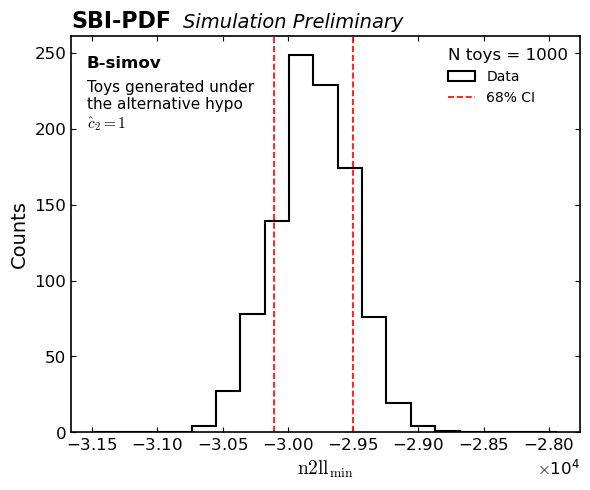

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# HEP-ish global style
plt.rcParams.update({
    "figure.figsize": (6, 5),
    "axes.linewidth": 1.2,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "mathtext.fontset": "cm",
})

# Calculate n_toys for the legend
n_toys = n2ll_mins.shape[0]

fig, ax = plt.subplots()

left, right = min(n2ll_mins[:, 0]), max(n2ll_mins[:, 0])
diff = right - left

# Histogram
ax.hist(
    n2ll_mins[:, 0],
    bins=np.linspace(left - diff/2, right + diff/2, 20),
    histtype="step",
    linewidth=1.5,
    color="black",
    label="Data"
)

# Calculate 68% quantiles
q16, q84 = np.percentile(n2ll_mins[:, 0], [16, 84])

# Vertical lines
ax.axvline(q16, color='red', linestyle='--', linewidth=1.2, label="68% CI")
ax.axvline(q84, color='red', linestyle='--', linewidth=1.2)

# --- 1. Text Box (Split for Bold Header) ---
ax.text(
    0.03, 0.95, 
    "B-simov", 
    transform=ax.transAxes, 
    fontsize=12, 
    weight='bold',
    verticalalignment='top'
)

body_text = (
    "Toys generated under\n"
    "the alternative hypo\n"
    r"$\hat{c}_{2} = 1$"
)

ax.text(
    0.03, 0.89,  # Slightly lower to sit below header
    body_text,
    transform=ax.transAxes, 
    fontsize=11,
    verticalalignment='top',
)

# --- 2. Custom Title (Split for Bold/Italic) ---
ax.text(
    0.0, 1.02, "SBI-PDF", 
    transform=ax.transAxes, 
    fontsize=16, 
    weight='bold', 
    ha='left', va='baseline'
)

ax.text(
    0.22, 1.02, "Simulation Preliminary", 
    transform=ax.transAxes, 
    fontsize=14, 
    style='italic', 
    ha='left', va='baseline'
)

import matplotlib.ticker as mtick
ax.xaxis.set_major_formatter(mtick.ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))

ax.set_xlabel(r"$\text{n2ll}_{{\min}}$")
ax.set_ylabel("Counts")
# ax.set_title(...) # Removed standard title

# --- 3. Legend (Aligned Left with Title) ---
ax.legend(
    title=f"N toys = {n_toys}",
    frameon=False, 
    loc="upper right",
    alignment='left',
    title_fontproperties={'size': 12}
)

plt.tight_layout()
plt.savefig('/users/alikaan.gueven/sbi-pdf/GOLLUM/user/kaan/figs/n2ll_min.pdf')
plt.savefig('/users/alikaan.gueven/sbi-pdf/GOLLUM/user/kaan/figs/n2ll_min.png')
plt.show()

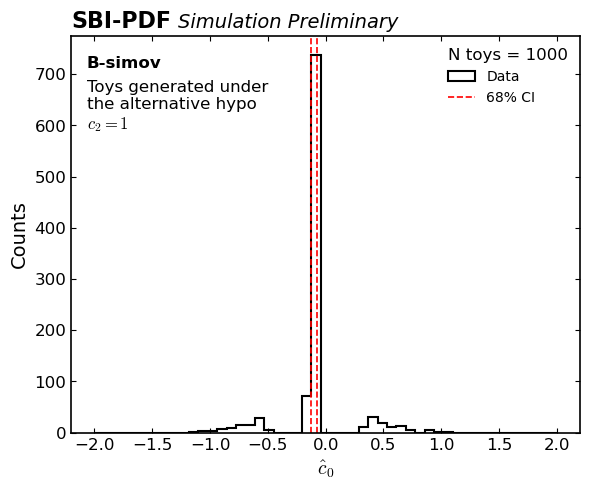

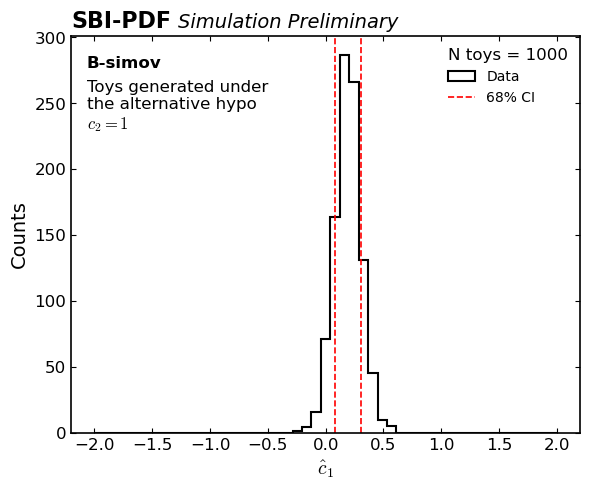

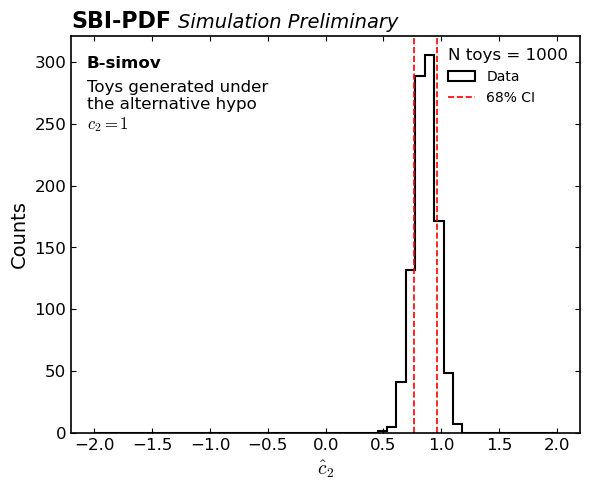

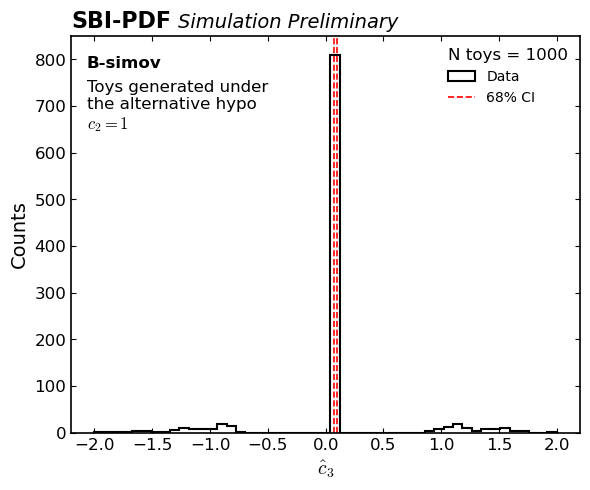

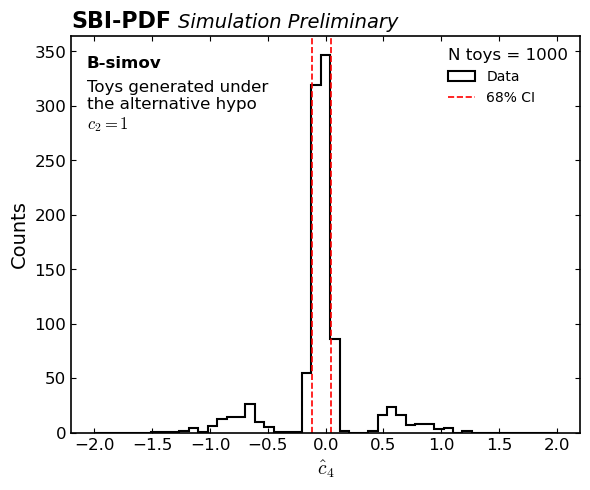

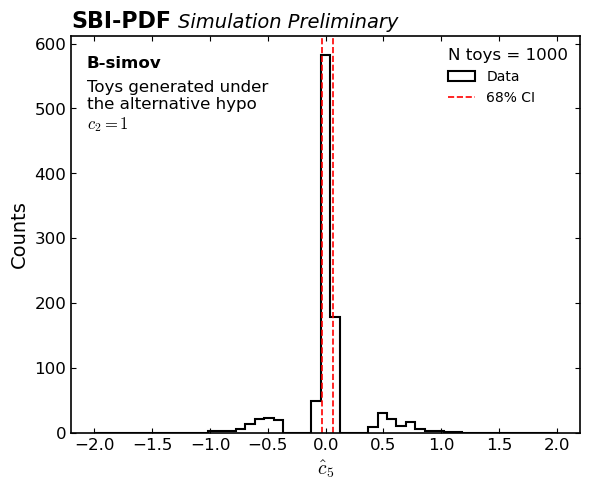

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Global style tweaks (HEP-ish)
plt.rcParams.update({
    "figure.figsize": (6, 5),
    "axes.linewidth": 1.2,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "mathtext.fontset": "cm", 
})

# Assuming c_hats is defined in your environment
n_cols = c_hats.shape[1]
n_toys = c_hats.shape[0]

for i in range(n_cols):
    fig, ax = plt.subplots()

    ax.hist(
        c_hats[:, i],
        bins=np.linspace(-2, 2, 50),
        histtype="step",
        linewidth=1.5,
        color="black",
        label="Data"
    )

    q25, q16, q84, q975 = np.percentile(c_hats[:, i], [2.5, 16, 84, 97.5])
    # ax.axvline(q25, color='red', linestyle=':', linewidth=1.2)
    ax.axvline(q16, color='red', linestyle='--', linewidth=1.2, label="68% CI")
    ax.axvline(q84, color='red', linestyle='--', linewidth=1.2)
    # ax.axvline(q975, color='red', linestyle=':', linewidth=1.2, label="95% CI")

    ax.text(
        0.03, 0.95, 
        "B-simov", 
        transform=ax.transAxes, 
        fontsize=12, 
        weight='bold',
        verticalalignment='top'
    )
    
    body_text = (
        "Toys generated under\n"
        "the alternative hypo\n"
        r"$c_{2} = 1$"
    )
    
    ax.text(
        0.03, 0.89,
        body_text,
        transform=ax.transAxes, 
        fontsize=12,
        verticalalignment='top',
    )

    ax.set_xlabel(rf"$\hat{{c}}_{i}$")
    ax.set_ylabel("Counts")
    
    ax.text(
        0.0, 1.02, "SBI-PDF", 
        transform=ax.transAxes, 
        fontsize=16, 
        weight='bold', 
        ha='left', va='baseline'
    )
    
    ax.text(
        0.21, 1.02, "Simulation Preliminary", 
        transform=ax.transAxes, 
        fontsize=14, 
        style='italic', 
        ha='left', va='baseline'
    )

    ax.legend(
        title=f"N toys = {n_toys}",
        frameon=False,
        alignment='left',
        title_fontproperties={'size': 12}
    )

    plt.tight_layout()
    plt.savefig(f'/users/alikaan.gueven/sbi-pdf/GOLLUM/user/kaan/figs/toy_fits_c_{i}.pdf')
    plt.savefig(f'/users/alikaan.gueven/sbi-pdf/GOLLUM/user/kaan/figs/toy_fits_c_{i}.png')
    plt.show()